In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
from jax.scipy.special import gamma, factorial
import scipy
import equinox as eqx
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time

from ABCMB import main, cosmology, perturbations, spectrum
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

/ext3/miniforge3/lib/python3.12/site-packages/jax/experimental/host_callback.py:34: UserWarning: jax.experimental.host_callback is deprecated and will be removed in JAX v0.8.0
  warnings.warn(


# Setup

In [4]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1193,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.247,
    'TCMB0': 2.34865418e-4,
    'T_nu': (4. / 11.)**(1. / 3.) * 2.34865418e-4,
    'N_ncdm': 0,
    'T_ncdm': 0.71611 * 2.34865418e-4,
    'm_ncdm': 0.06,
}

In [14]:
model = main.Model(ellmin=2, ellmax=2500, lensing=False, has_MassiveNeutrinos=False)
for i in range(2):
    s = time.time()
    PT, BG = model.get_PTBG(params)
    print(time.time() - s)
params = model.add_derived_parameters(params)

72.84200692176819
12.594722509384155


In [15]:
for i in range(1):
    s = time.time()
    class_params = {
        "output": "mPk, tCl, pCl",
        #"temperature_contributions" : "tsw",
        "l_max_scalars" : 2500,
        "z_max_pk": 1000,
        "lensing" : "no",
        "H0": params["h"]*100,
        "omega_b": params["omega_b"],
        "omega_cdm": params["omega_cdm"],
        "A_s" : params["A_s"],
        "n_s" : params["n_s"],
        "N_ur": params["N_ur"],
        "YHe": params["YHe"],
        "N_ncdm": params["N_ncdm"],
        #"reio_parametrization" : "reio_none",
        "reio_parametrization" : "reio_camb",
        "z_reio" : 11,
        "reionization_width" : 0.5,
        "helium_fullreio_redshift" : 3.5,
        "helium_fullreio_width" : 0.5,
        "reionization_exponent" : 1.5,
        "l_max_g": 12,
        "l_max_pol_g": 10,
        "l_max_ur": 17, 
        "l_max_ncdm":17,
        "radiation_streaming_trigger_tau_over_tau_k" : 20000,
        "radiation_streaming_trigger_tau_c_over_tau" : 2,
        "ur_fluid_trigger_tau_over_tau_k" : 10000} 
    class_lcdm = Class()
    class_lcdm.set(class_params)
    class_lcdm.compute()
    print(time.time() - s)

17.862361907958984


# Thermodynamics Check

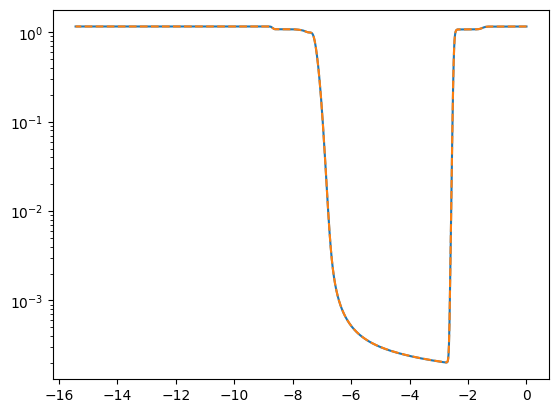

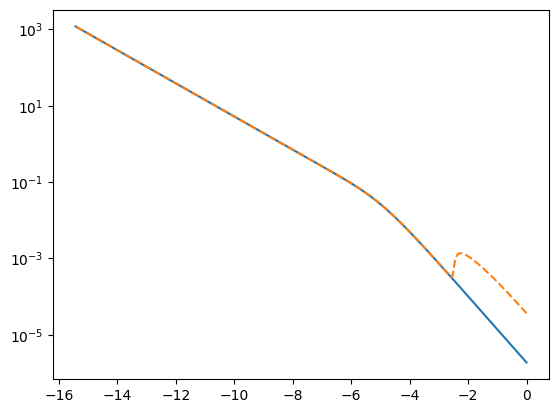

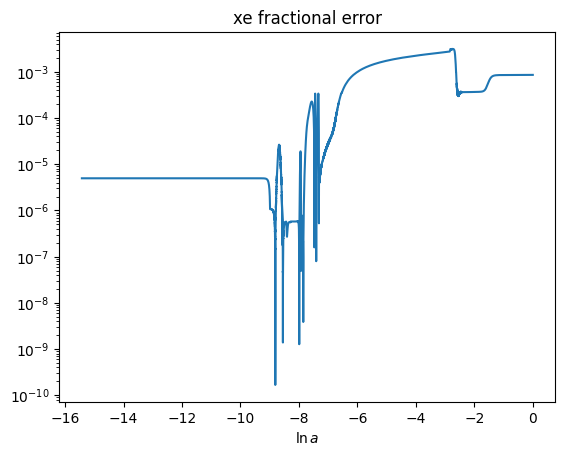

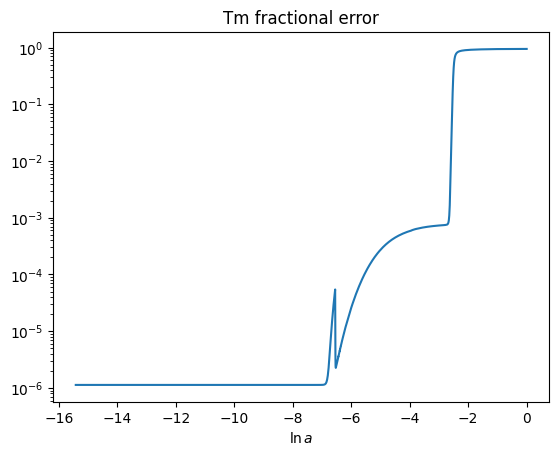

In [16]:
class_rec = class_lcdm.get_thermodynamics()
a = 1/(1.+class_rec["z"])
xe_class = class_rec["x_e"]
Tm_class = class_rec['Tb [K]'] * cnst.kB
xe_abcmb = BG.xe(jnp.log(a))
Tm_abcmb = BG.Tm(jnp.log(a))

plt.plot(jnp.log(a), xe_abcmb)
plt.plot(jnp.log(a), xe_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), Tm_abcmb)
plt.plot(jnp.log(a), Tm_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(xe_abcmb-xe_class)/xe_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(Tm_abcmb-Tm_class)/Tm_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Tm fractional error")
plt.show()

In [18]:
expmkappa_class = class_rec["exp(-kappa)"]
g_class = class_rec["g [Mpc^-1]"]
expmkappa_abcmb = vmap(BG.expmkappa)(jnp.log(a))
g_abcmb = vmap(BG.visibility)(jnp.log(a))

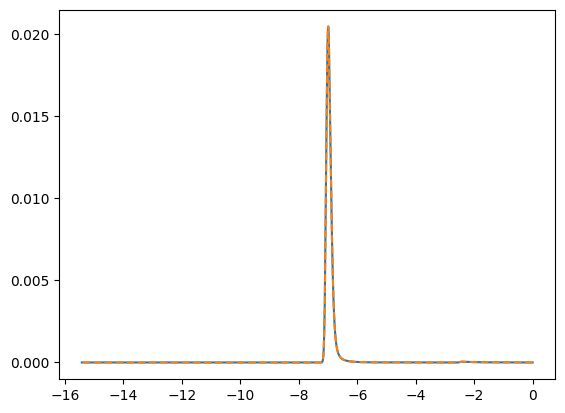

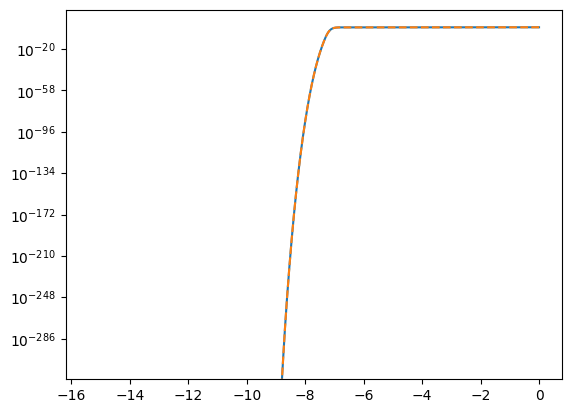

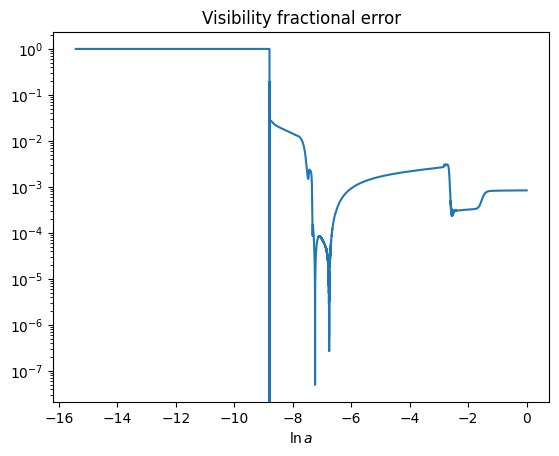

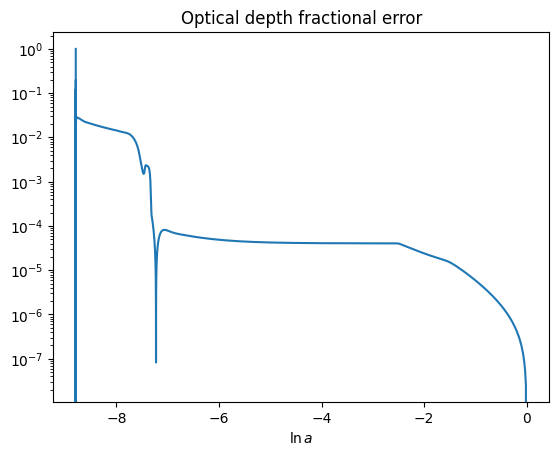

In [21]:
plt.plot(jnp.log(a), g_abcmb)
plt.plot(jnp.log(a), g_class, "--")
plt.show()

plt.plot(jnp.log(a), expmkappa_abcmb)
plt.plot(jnp.log(a), expmkappa_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(g_abcmb-g_class)/g_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("Visibility fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(expmkappa_abcmb-expmkappa_class)/expmkappa_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Optical depth fractional error")
plt.show()

# Cl's

In [22]:
#class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(2500)["tt"]
class_te = class_lcdm.raw_cl(2500)["te"]
class_ee = class_lcdm.raw_cl(2500)["ee"]
class_ell = class_lcdm.raw_cl(2500)["ell"]

In [23]:
f = eqx.filter_jit(model.SS.get_Cl_vmap)
for i in range(2):
    s=time.time()
    ells, tt, te, ee = f(PT, BG, params)
    tt.block_until_ready()
    print(time.time()-s)

61.5293869972229
0.1217501163482666


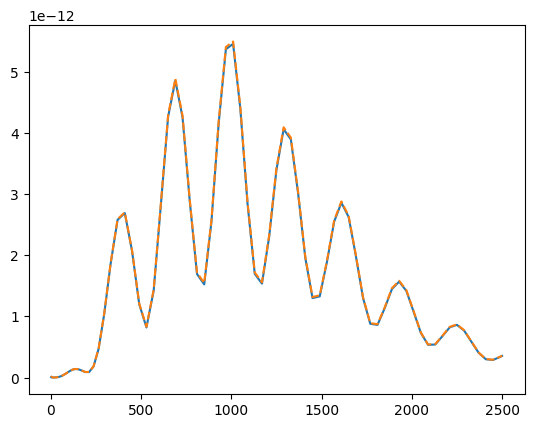

In [26]:
l = ells
plt.plot(l, l*(l+1)*ee/2./jnp.pi)
plt.plot(l, l*(l+1)*jnp.interp(l, class_ell, class_ee)/2./jnp.pi, "--")
#plt.xlim((180, 220))
plt.show()

In [5]:
class_pk = np.loadtxt("/home/zz1994/packages/class/output/ABCMB_test/noneutrinos00_pk.dat")
k_class = class_pk[:, 0]*BG.params["h"]
Pk_class = class_pk[:, 1]/BG.params["h"]**3

In [15]:
k = jnp.logspace(-4., -0.3, 500, base=10)
Pk = SS.Pk_lin(k, 0., PT, BG)

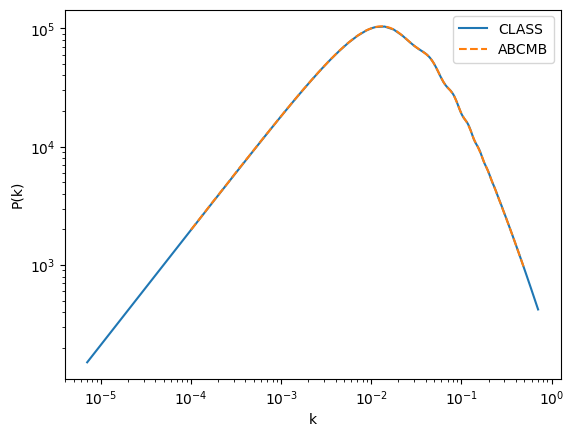

In [16]:
plt.loglog(k_class, Pk_class, label="CLASS")
plt.loglog(k, Pk, "--", label="ABCMB")
plt.legend()
#plt.xlim((1.e-3, 1))
plt.xlabel("k")
plt.ylabel("P(k)")
plt.show()

In [7]:
from classy import Class

In [16]:
class_params = {
    "output": "mPk, lCl",
    "lensing": "yes",
    "z_max_pk": 1000,
    "H0": BG.params["h"]*100,
    "omega_b": BG.params["omega_b"],
    "omega_cdm": BG.params["omega_cdm"],
    "tau_reio": 0.0586,
    "N_ur": BG.params["N_ur"],
    "YHe": BG.params["YHe"],
    "lensing": "no",
    "N_ncdm": 0}    

In [17]:
class_lcdm = Class()
class_lcdm.set(class_params)
class_lcdm.compute()

In [18]:
zs = jnp.array([0., 10., 100., 1000.])
k = jnp.logspace(-4., -0.3, 500, base=10)

/state/partition1/job-66401383/ipykernel_1291522/4275723911.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


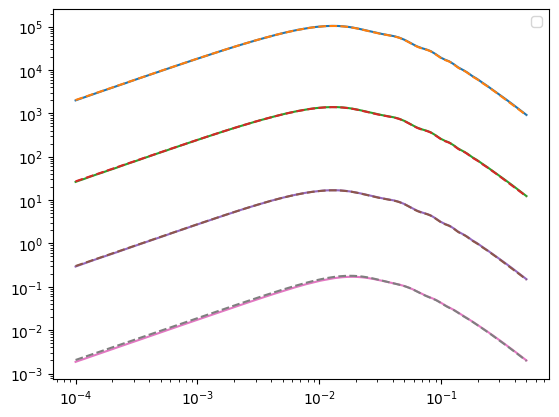

In [25]:
for z in zs:
    abcmb_res = SS.Pk_lin(k, z, PT, BG)
    class_res = np.vectorize(class_lcdm.pk_lin)(k, z)
    plt.loglog(k, SS.Pk_lin(k, z, PT, BG))
    plt.loglog(k, np.vectorize(class_lcdm.pk_lin)(k, z), "--")
    #plt.loglog(k, abs(abcmb_res - class_res)/class_res, label=z)
plt.legend()
plt.show()

# Lensing

## Lensing Cl

In [30]:
class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(3000)["tt"]
class_te = class_lcdm.raw_cl(3000)["te"]
class_ee = class_lcdm.raw_cl(3000)["ee"]
class_ell = class_lcdm.raw_cl(3000)["ell"]
abcmb_pp = vmap(SS.lensing_Cl, in_axes=(0, None, None))(class_ell, PT, BG)

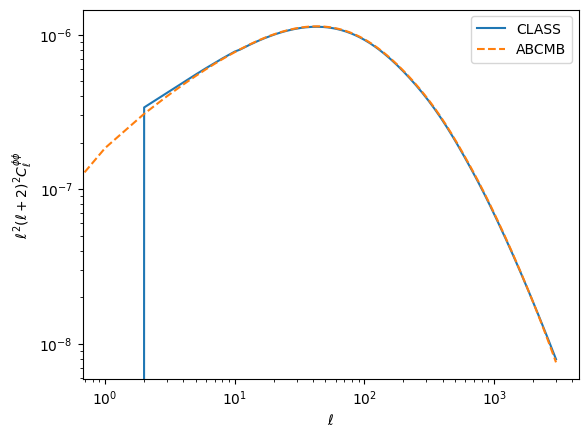

In [31]:
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * class_pp, label="CLASS")
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * abcmb_pp, "--", label="ABCMB")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell^2(\ell+2)^2C_\ell^{\phi\phi}$")
plt.show()

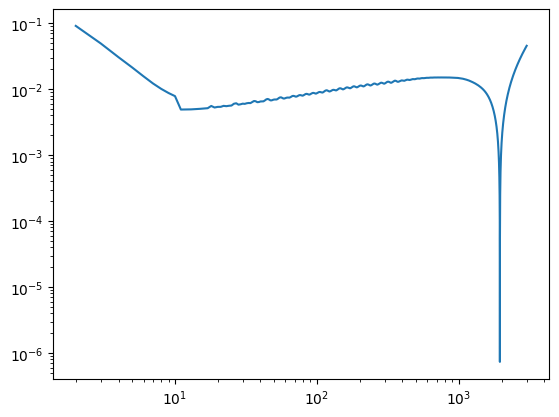

In [32]:
plt.plot(class_ell, abs(class_pp - abcmb_pp)/class_pp)
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.show()

## Temperature Cl

$$
C_\ell = \int_{0.98}^{1} \xi(\beta) J_0(\ell \beta) d\cos{\beta}
$$

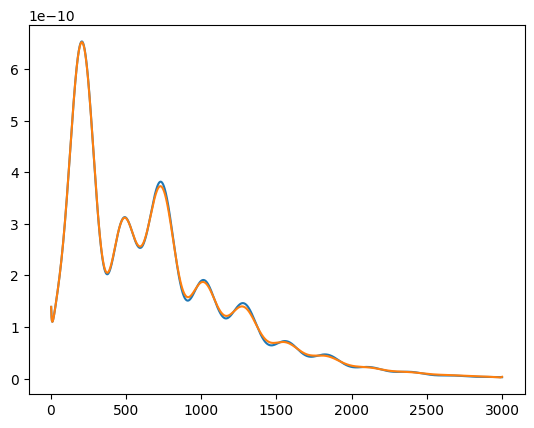

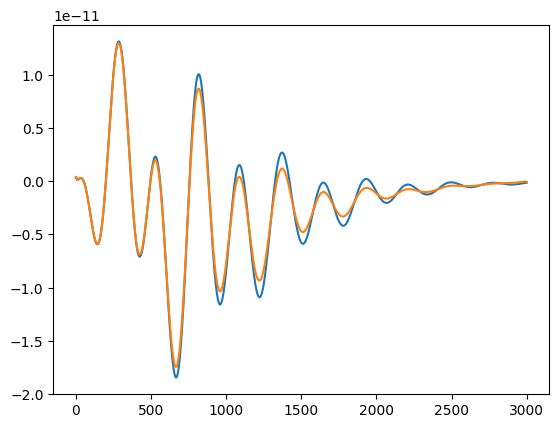

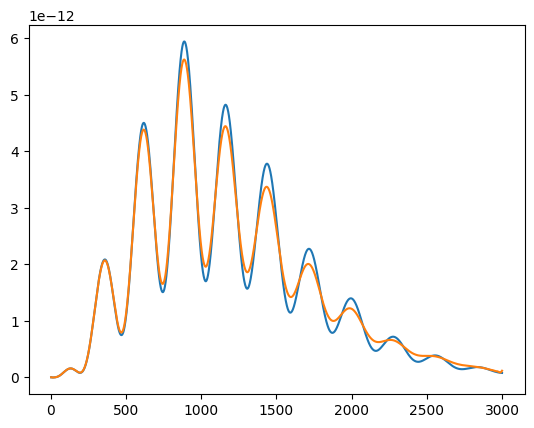

In [36]:
#res = SS.lense_ClTT(class_ell[2:], class_pp[2:], class_ell[2:]*(class_ell[2:]+1)*class_tt[2:]/2./jnp.pi)
#plt.loglog(class_ell[2:], class_ell[2:]*(class_ell[2:]+1)*res)
#ells = jnp.arange(2, 2000)
ells = class_ell[2:]
cltt = class_tt[2:]
clte = class_te[2:]
clee = class_ee[2:]
clpp = class_pp[2:]
pref = ells*(ells+1)/2./jnp.pi
#clpp = jnp.zeros(ells.size)
res_tt, res_te, res_ee = eqx.filter_jit(SS.lensed_Cls)(ells, cltt, clte, clee, PT, BG)
plt.plot(ells, pref*cltt)
plt.plot(ells, pref*(res_tt+cltt))
plt.show()

plt.plot(ells, pref*clte)
plt.plot(ells, pref*(res_te+clte))
plt.show()

plt.plot(ells, pref*clee)
plt.plot(ells, pref*(res_ee+clee))
plt.show()

In [47]:
f = eqx.filter_jit(SS.lensed_Cls)
for i in range(2):
    s = time.time()
    res_tt, res_te, res_ee = f(ells, cltt, clte, clee, PT, BG)
    res_tt.block_until_ready()
    print(time.time() - s)

16.553486347198486
11.142034769058228


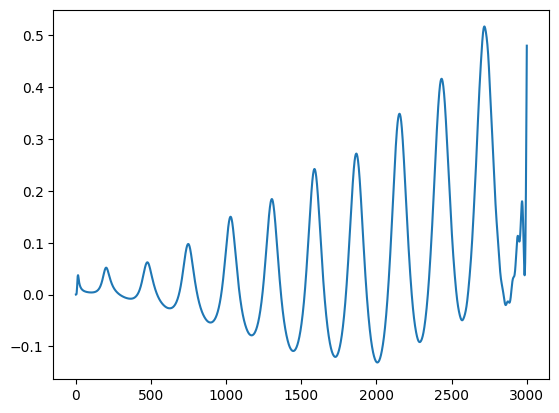

In [304]:
#plt.plot(ells, res_tt/cltt)
#plt.plot(ells, res_te/clte)
plt.plot(ells, res_ee/clee)
plt.show()

## Wigner Matrices

In [104]:
f = jit(tools.lensing_d00)
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1003)
mu    = jnp.cos(betas)
print(f(mu, l).shape)

(1000, 1001)


In [55]:
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1000)
mu    = jnp.cos(betas)

d00  = tools.lensing_d00(mu, l)
d11  = tools.lensing_d11(mu, l)
d1m1 = tools.lensing_d1m1(mu, l)
d2m2 = tools.lensing_d2m2(mu, l)

In the large $\ell$ limit, the Wigner matrices approach Bessel J functions as
$$
\lim_{\ell\rightarrow \infty}d_{mn}^{\ell}(\beta) \longrightarrow (-1)^{n-m} J_{m-n}(\ell \beta)\, .
$$
It serves to check the asymptotic behavior to make sure the recursion relations were correct.

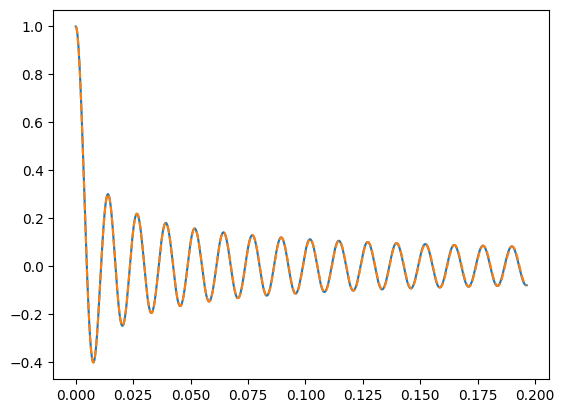

In [19]:
l = 500
plt.plot(betas, d00[:, l-2])
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

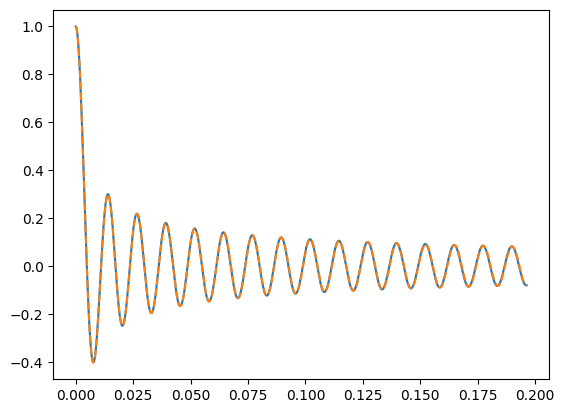

In [20]:
l = 500
plt.plot(betas, d11[:, l-2], label="d11")
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

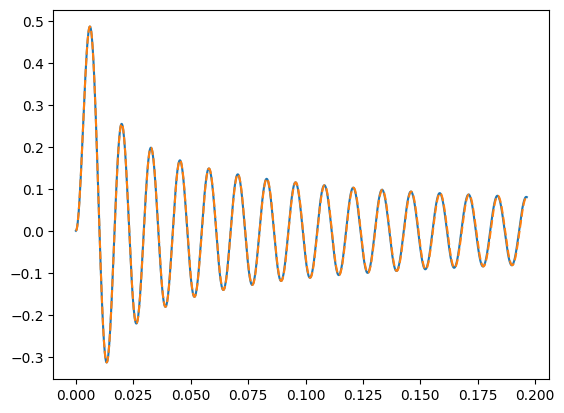

In [21]:
l = 500
plt.plot(betas, d1m1[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(2, l*betas), "--")
plt.show()

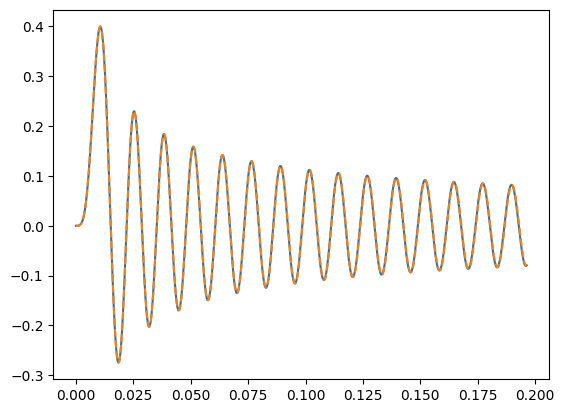

In [62]:
l = 500
plt.plot(betas, d2m2[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(4, l*betas), "--")
plt.show()

In [233]:
# Attempt at general solution
def wigner_d_matrix(mu, ells, m, n):
    """
    m, n are integers. m must be positive and greater than n.
    ells an array ([m, m+1, m+2, ..., ellmax])
    """
    
    # base case: ell = m
    def base_val(mu):
        beta = jnp.arccos(mu)
        norm = jnp.sqrt((2*m+1)/2) * jnp.sqrt(factorial(2*m)/(factorial(m+n)*factorial(m-n)))
        return norm * jnp.cos(beta/2.)**(m+n)*(-jnp.sin(beta/2.))**(m-n)
        #return norm * jnp.sqrt((1+mu)/2)**(m+n) * jnp.sqrt((1-mu)/2)**(m-n)

    normA = jnp.sqrt((2*ells+3)/(2*ells+1))
    normC = jnp.sqrt((2*ells+3)/(2*ells-1))
    denom = jnp.sqrt((ells+1)**2-m**2) * jnp.sqrt((ells+1)**2-n**2)
    A = jnp.nan_to_num(normA * (ells+1)*(2*ells+1) / denom, 0)
    B = jnp.nan_to_num(-A * m * n / ells / (ells+1), 0)
    C = jnp.nan_to_num(-normC * jnp.sqrt(ells**2-m**2) * jnp.sqrt(ells**2-n**2) / denom * (ells+1)/ells, 0)

    def one_mu(mu):
        d_start = base_val(mu) # Corresponds to ellmin = m
                
        def recursive_dlp1(carry, inputs):
            # For the first iteration, will take d1 and d2, compute d3.
            dl, dlm1 = carry 
            a, b, c = inputs

            # Compute dlp1
            dlp1 = a*mu*dl + b*dl + c*dlm1

            # Save dl, then make dl->dlm1, dlp1->dl
            return (dlp1, dl), dl

        # run scan for l = 2..lmax-1
        (_, _), res = lax.scan(recursive_dlp1, (d_start, 0.), (A, B, C))
        return res * jnp.sqrt(2./(2.*ells+1))

    return vmap(one_mu)(mu)

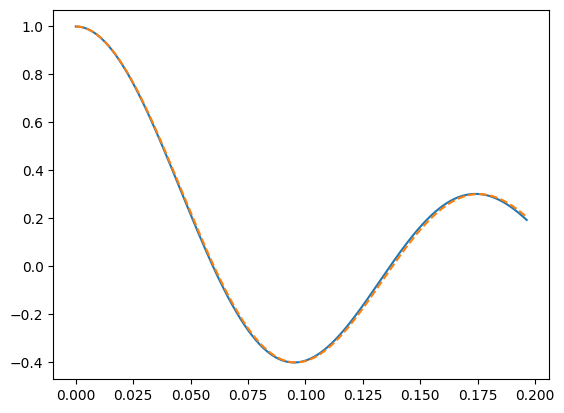

In [245]:
m = 4
n = 4
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(m, 1000)
mu    = jnp.cos(betas)
d = jit(wigner_d_matrix)(mu, l, m, n)

l_plot = 10*m
plt.plot(betas, d[:, l_plot-m])
plt.plot(betas, (-1)**(n-m)*scipy.special.jv(m-n, l_plot*betas), "--")
plt.show()

In [248]:
d.shape
zeros = jnp.zeros((mu.size, m-2))
d_patched = jnp.concatenate((zeros, d), axis=1)

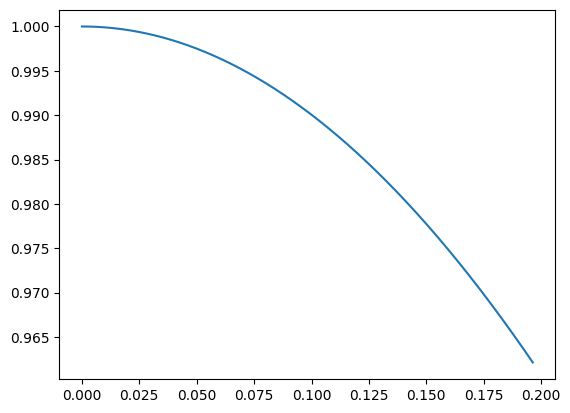

In [252]:
plt.plot(betas, d_patched[:, 2])

In [280]:
arr = jnp.ones(5)

5